# Capstone Project EDA
End-to-end exploratory data analysis across NAV trends, AUM, SIP inflows, investor demographics, geographic distribution, correlations, and sector allocation.

In [3]:
# ── Cell 1 — Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
import os 
print(os.getcwd())

C:\Users\Sai Khedekar\Desktop\CapstoneProject_1\notebooks


In [5]:
# ── Cell 2 — Load Data ────────────────────────────────────────────────────────
DATA_DIR = Path("../data/processed")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)
nav       = pd.read_csv(DATA_DIR / "clean_02_nav_history.csv")
aum       = pd.read_csv(DATA_DIR / "clean_03_aum_by_fund_house.csv")
sip       = pd.read_csv(DATA_DIR / "Clean_04_monthly_sip_inflows.csv")
cat       = pd.read_csv(DATA_DIR / "clean_05_category_inflows.csv")
txn       = pd.read_csv(DATA_DIR / "clean_08_investor_transactions.csv")
portfolio = pd.read_csv(DATA_DIR / "clean_09_portfolio_holdings.csv")

In [6]:
# ── Cell 3 — Date Parsing ─────────────────────────────────────────────────────
nav["date"]                    = pd.to_datetime(nav["date"])
aum["date"]                    = pd.to_datetime(aum["date"])
sip["month"]                   = pd.to_datetime(sip["month"])
cat["month"]                   = pd.to_datetime(cat["month"])
txn["transaction_date"]        = pd.to_datetime(txn["transaction_date"])
portfolio["portfolio_date"]    = pd.to_datetime(portfolio["portfolio_date"])

---
## Section 1 — NAV Trend Analysis

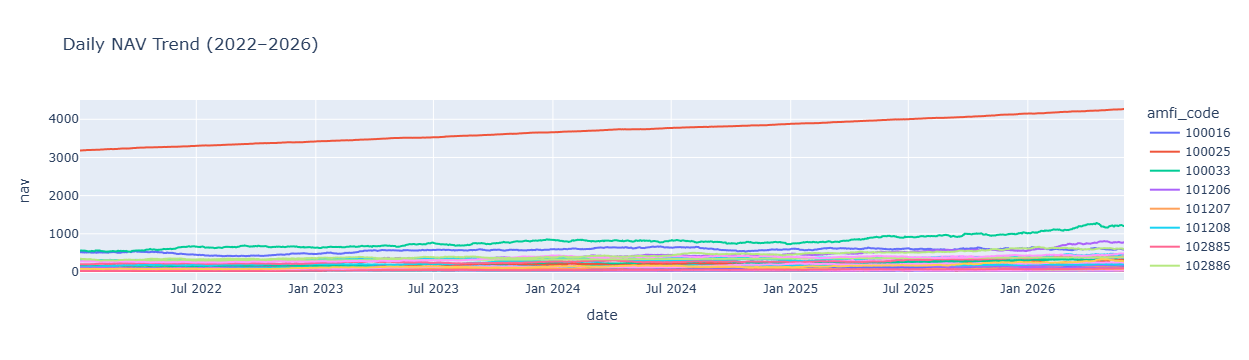

In [7]:
# Chart 1 — All Schemes NAV Trend
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.write_image(
    CHART_DIR / "all_schemes_nav_trend.png",
    width=1200,
    height=600,
    scale=2         
)

fig.show()

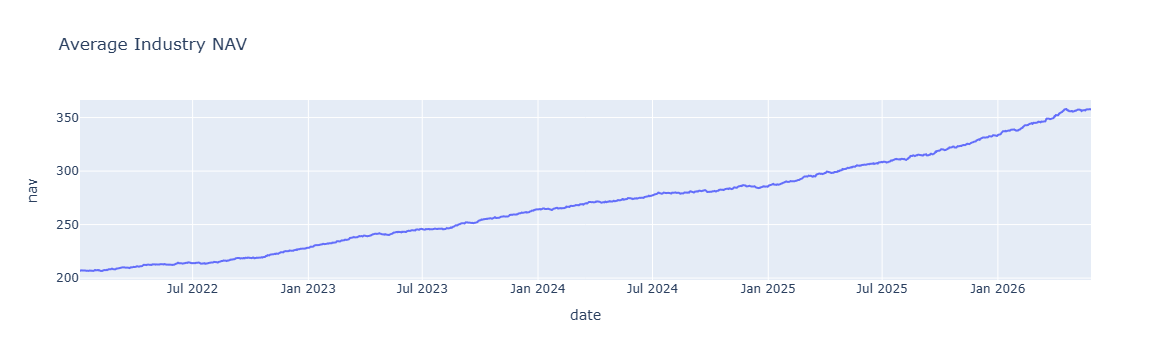

In [8]:
# Chart 2 — Average NAV Across Industry
avg_nav = (
    nav.groupby("date")["nav"]
    .mean()
    .reset_index()
)

fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Industry NAV"
)

fig.write_image(
    CHART_DIR / "average_nav.png",
    width=1200,
    height=600,
    scale=2          
)
fig.show()

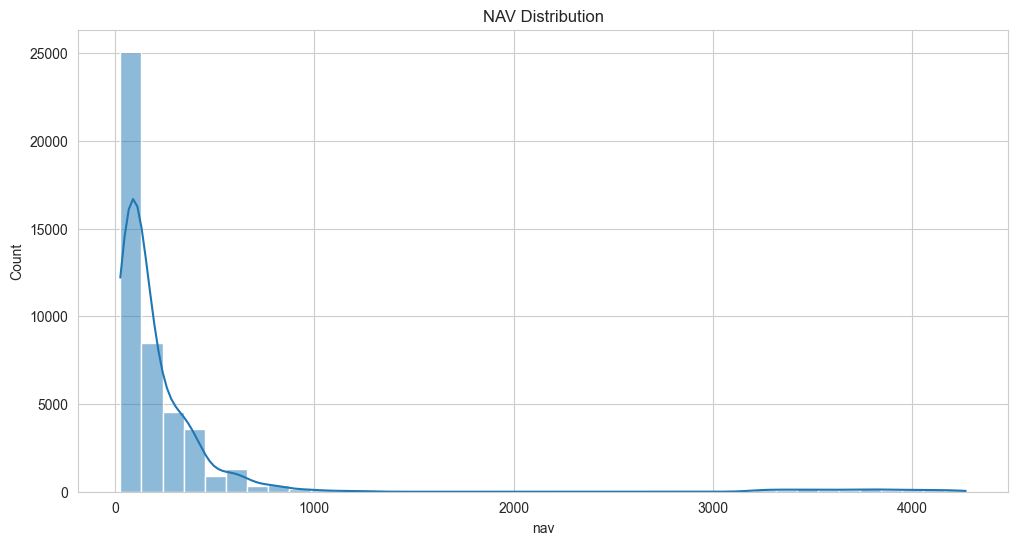

In [9]:
# Chart 3 — NAV Distribution
sns.histplot(nav["nav"], bins=40, kde=True)
plt.title("NAV Distribution")

plt.savefig(CHART_DIR / "nav_distribution.png", dpi=300, bbox_inches="tight")

plt.show()



### Insight 1
Industry NAV generally shows long-term upward movement indicating growth in fund values.

---
## Section 2 — AUM Analysis

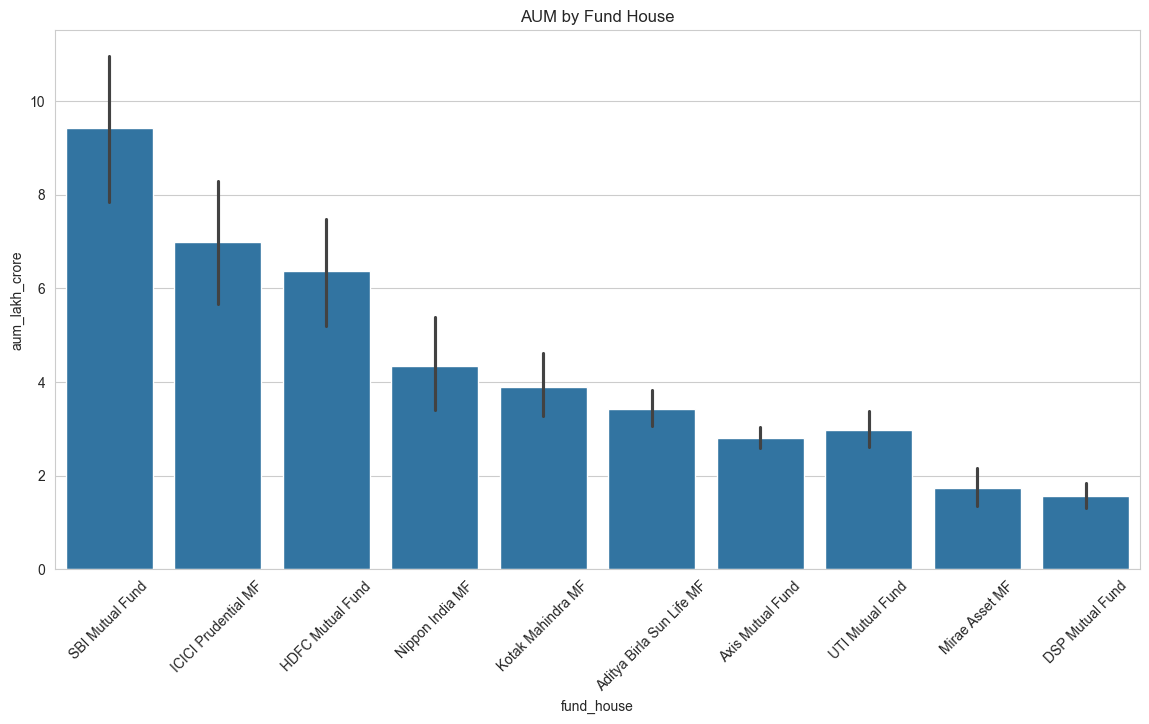

In [10]:
# Chart 4 — AUM by Fund House
plt.figure(figsize=(14, 7))
sns.barplot(data=aum, x="fund_house", y="aum_lakh_crore")
plt.xticks(rotation=45)
plt.title("AUM by Fund House")
plt.savefig(CHART_DIR / "aum_by_fund_house.png", dpi=300, bbox_inches="tight")
plt.show()

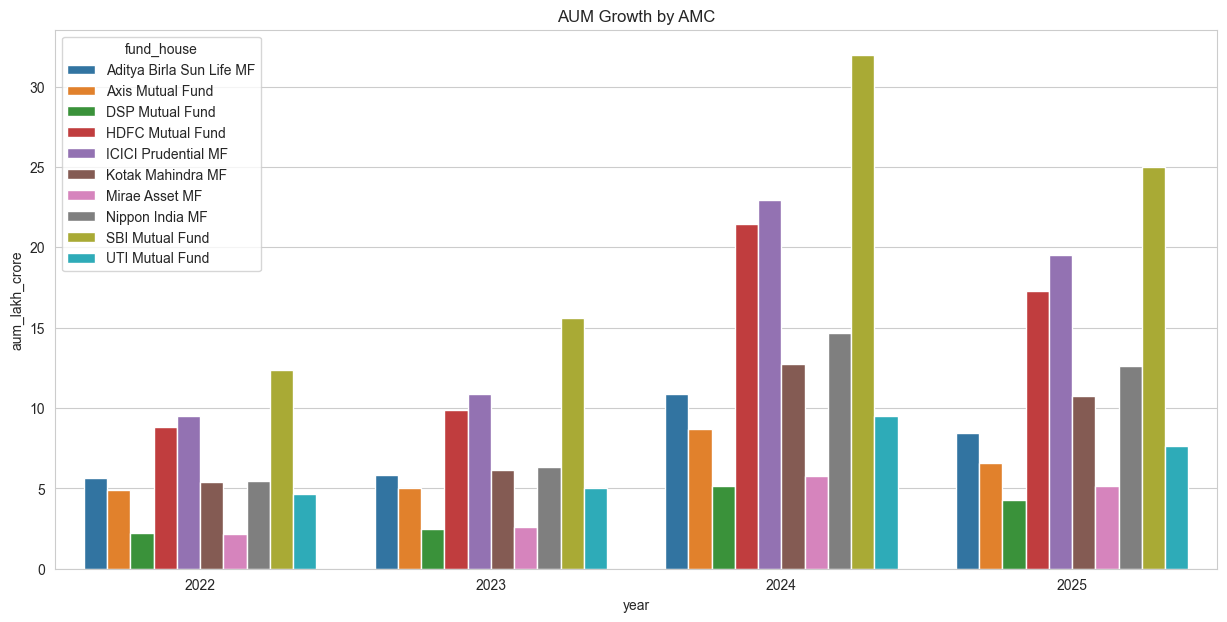

In [11]:
# Chart 5 — Grouped Year-wise AUM
aum["year"] = aum["date"].dt.year

pivot = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 7))
sns.barplot(data=pivot, x="year", y="aum_lakh_crore", hue="fund_house")
plt.title("AUM Growth by AMC")
plt.savefig(CHART_DIR / "aum_growth_by_amc.png", dpi=300, bbox_inches="tight")
plt.show()

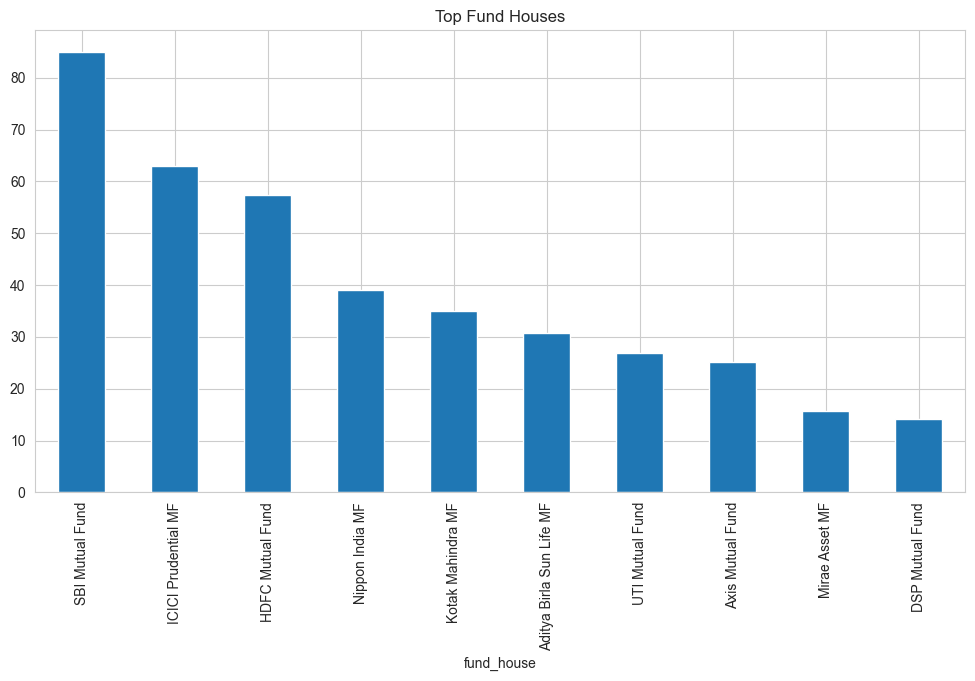

In [12]:
# Chart 6 — Top 10 Fund Houses
top = (
    aum.groupby("fund_house")["aum_lakh_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top.plot(kind="bar")
plt.title("Top Fund Houses")
plt.savefig(CHART_DIR / "top_fund_houses.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 3 — SIP Analysis

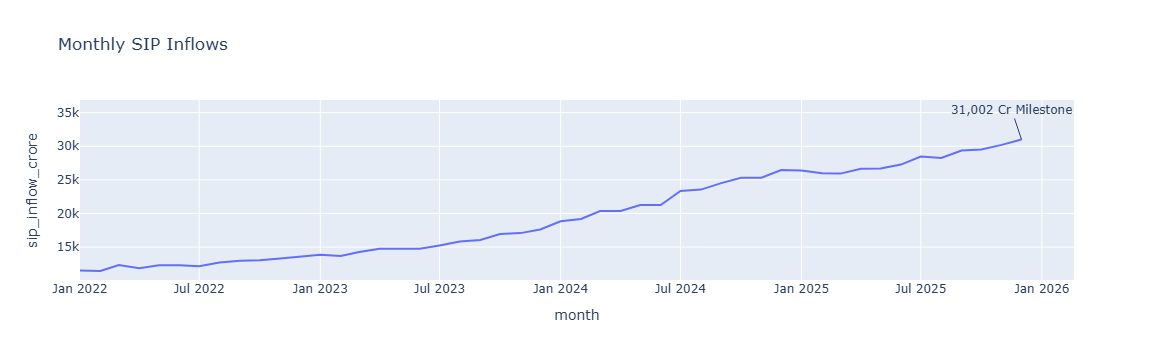

In [24]:
# Chart 7 — SIP Inflow Trend
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)
fig.add_annotation(
    x=str(sip.iloc[-1]["month"]),
    y=sip["sip_inflow_crore"].max(),
    text="31,002 Cr Milestone"
)
fig.write_image(CHART_DIR / "sip_inflow_trend.png", width=1200, height=600, scale=2)
fig.show()

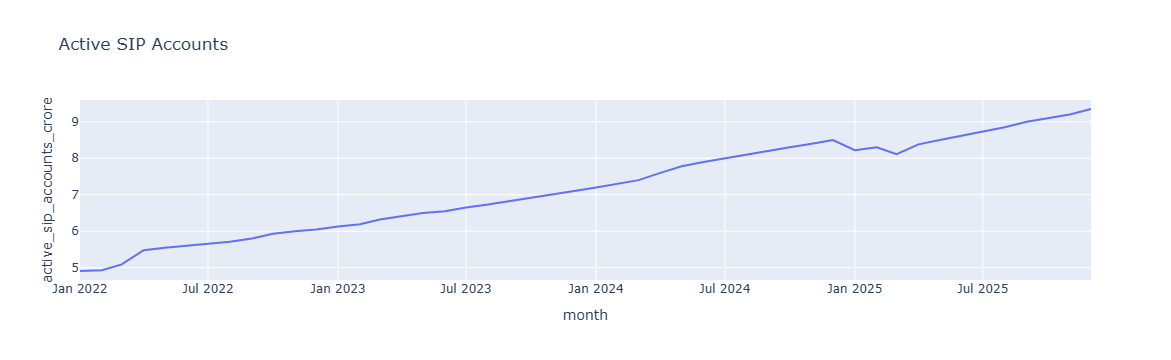

In [14]:
# Chart 8 — SIP Account Growth
fig8 = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    title="Active SIP Accounts"
)
fig8.write_image(CHART_DIR / "sip_account_growth.png", width=1200, height=600, scale=2)
fig8.show()

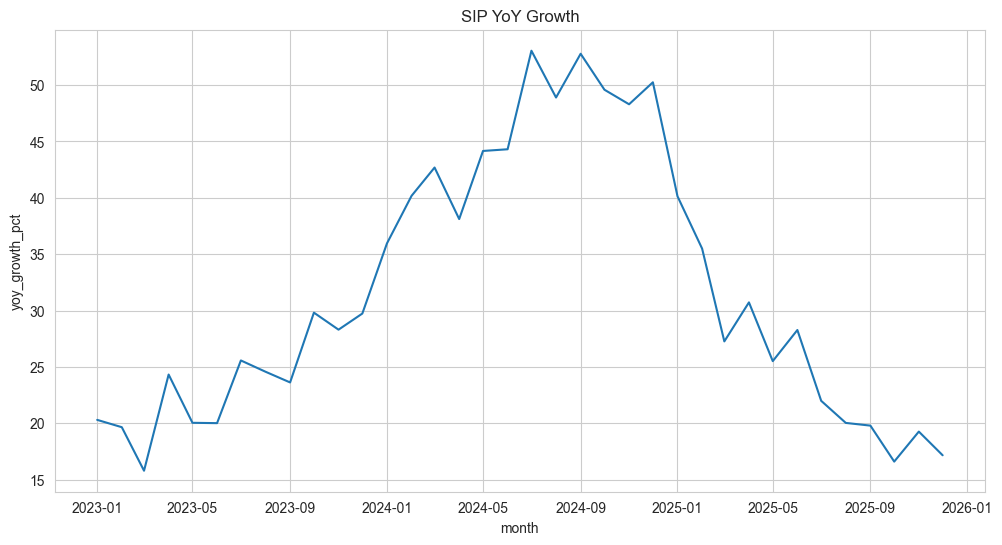

In [15]:
# Chart 9 — YoY Growth %
sns.lineplot(data=sip, x="month", y="yoy_growth_pct")
plt.title("SIP YoY Growth")
plt.savefig(CHART_DIR / "sip_yoy_growth.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 4 — Category Inflow Heatmap

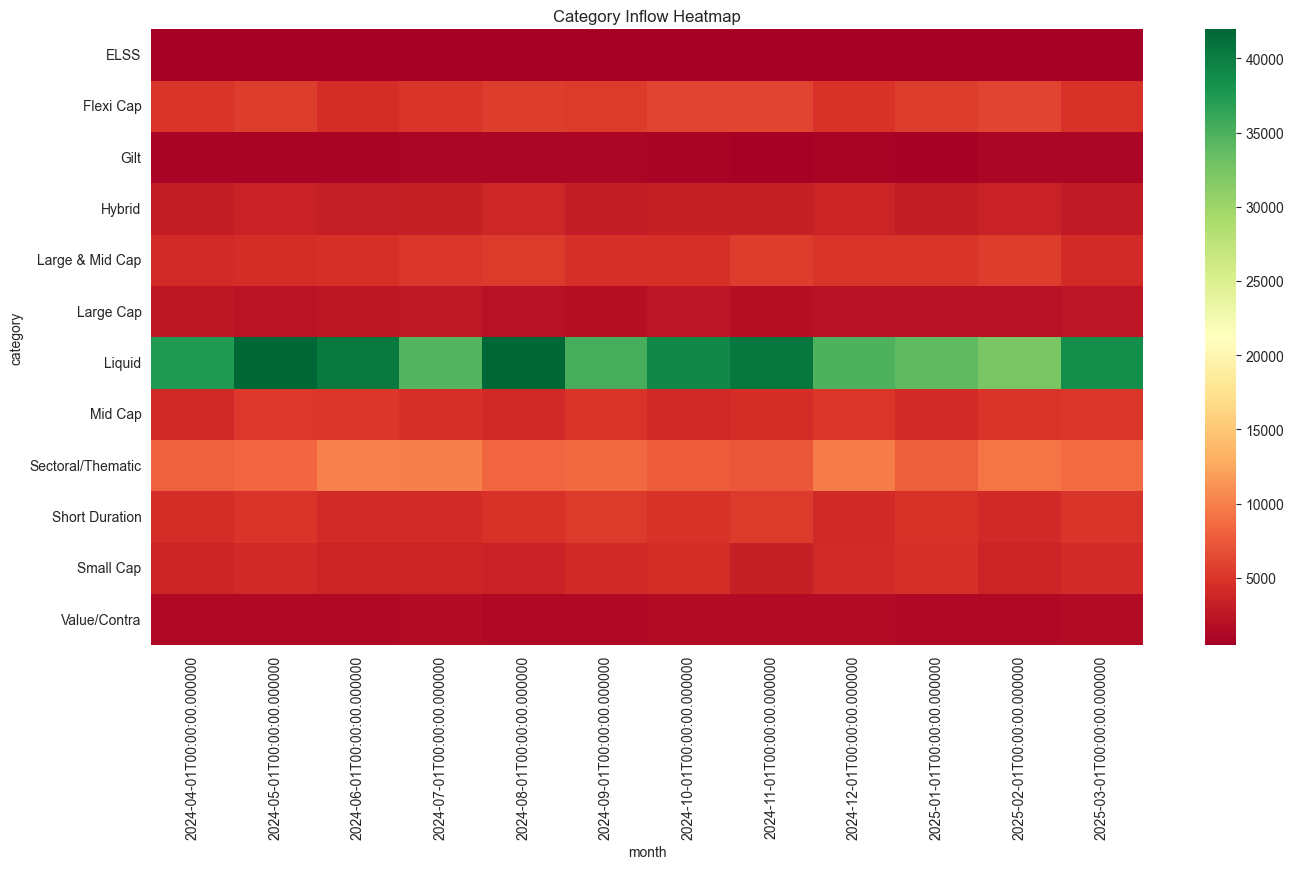

In [16]:
# Chart 10 — Category Inflow Heatmap
heat = cat.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16, 8))
sns.heatmap(heat, cmap="RdYlGn")
plt.title("Category Inflow Heatmap")
plt.savefig(CHART_DIR / "category_inflow_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 5 — Investor Demographics

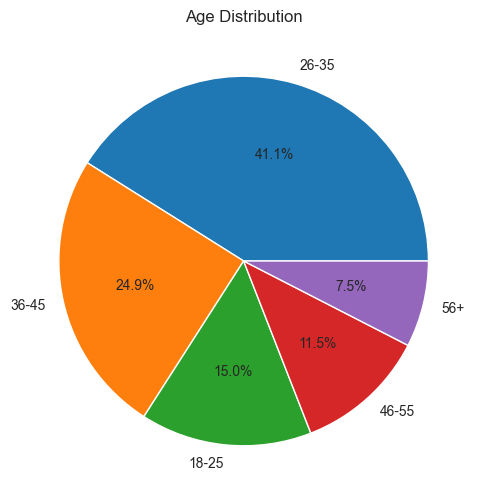

In [17]:
# Chart 11 — Age Group Distribution
txn["age_group"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Age Distribution")
plt.savefig(CHART_DIR / "age_group_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

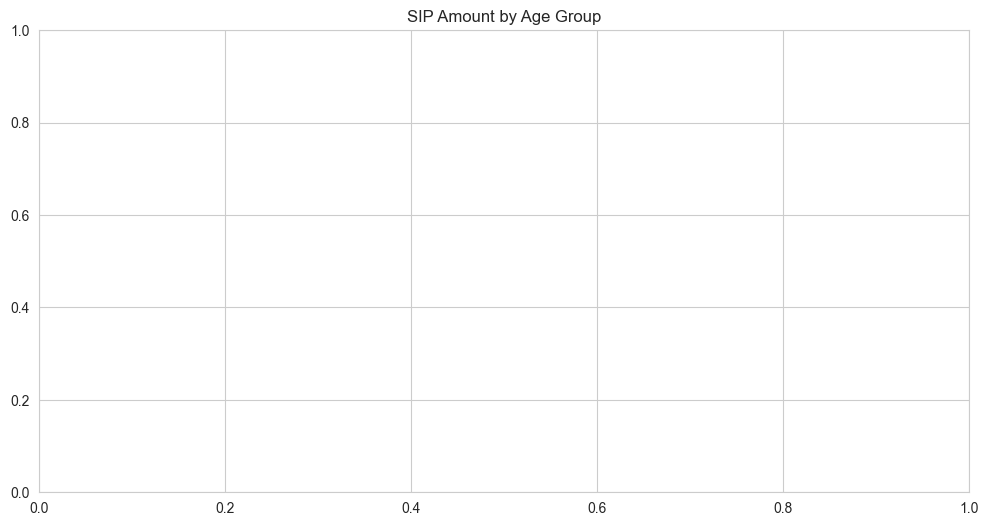

In [18]:
# Chart 12 — SIP Amount by Age Group
sip_txn = txn[txn["transaction_type"] == "SIP"]

sns.boxplot(data=sip_txn, x="age_group", y="amount_inr")
plt.title("SIP Amount by Age Group")
plt.savefig(CHART_DIR / "sip_amount_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

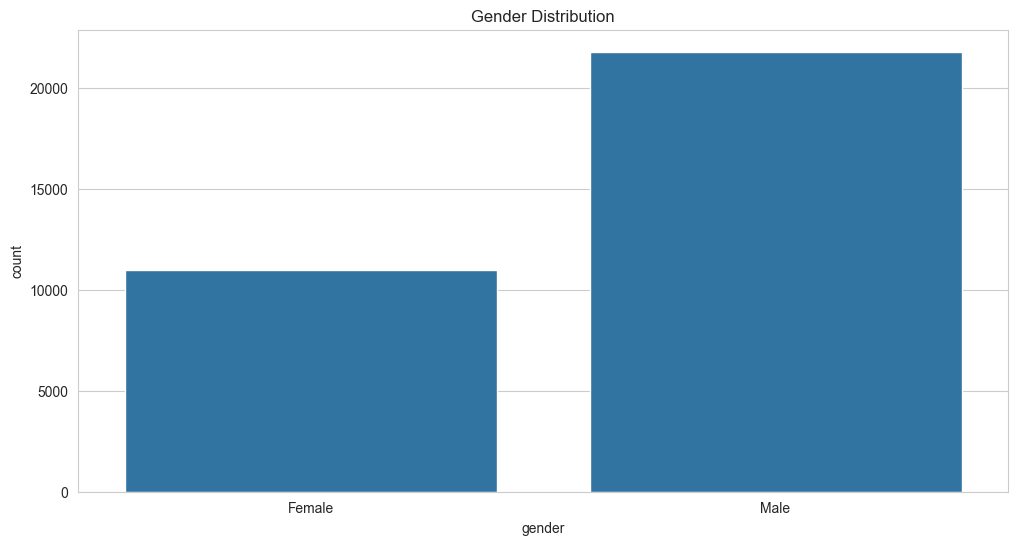

In [19]:
# Chart 13 — Gender Split
sns.countplot(data=txn, x="gender")
plt.title("Gender Distribution")
plt.savefig(CHART_DIR / "gender_split.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 6 — Geographic Analysis

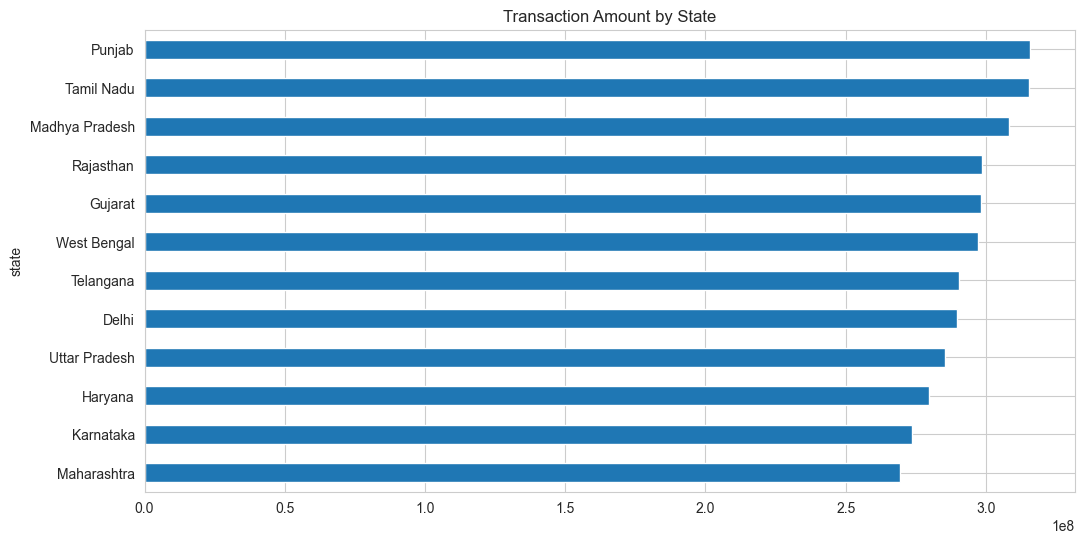

In [20]:
# Chart 14 — State-wise Transaction Amount
state_amt = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

state_amt.plot(kind="barh")
plt.title("Transaction Amount by State")
plt.savefig(CHART_DIR / "state_transaction_amount.png", dpi=300, bbox_inches="tight")
plt.show()

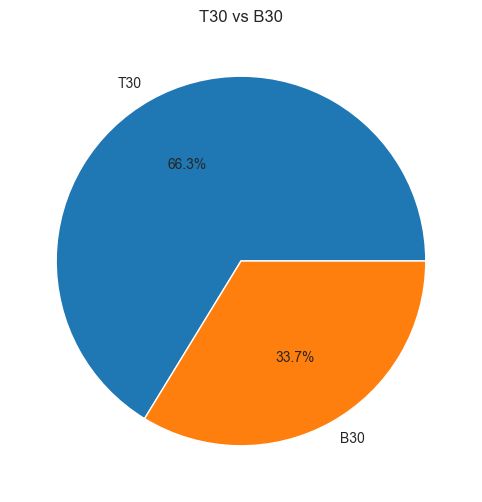

In [21]:
# Chart 15 — T30 vs B30
txn["city_tier"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("T30 vs B30")
plt.savefig(CHART_DIR / "city_tier_split.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 7 — NAV Correlation Matrix

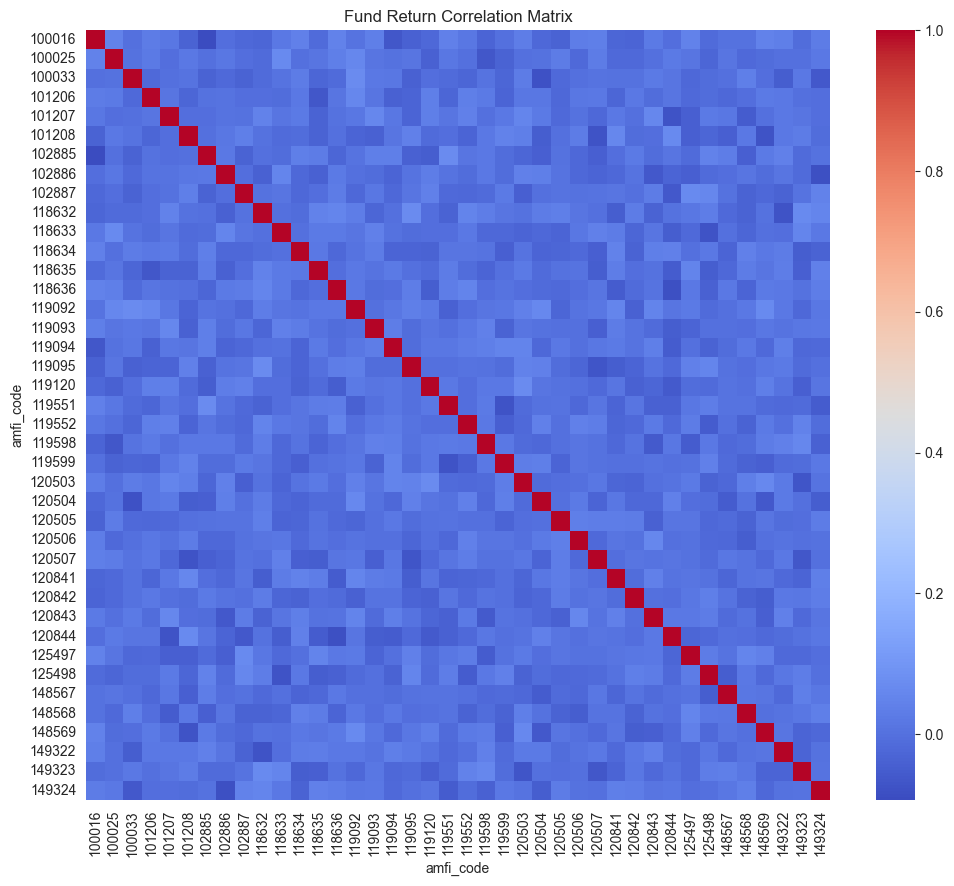

In [22]:
# Chart 16 — Fund Return Correlation Matrix
returns = nav.copy()
returns["daily_return"] = (
    returns.groupby("amfi_code")["nav"].pct_change()
)

pivot = returns.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr = pivot.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Fund Return Correlation Matrix")
plt.savefig(CHART_DIR / "fund_return_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 8 — Sector Allocation

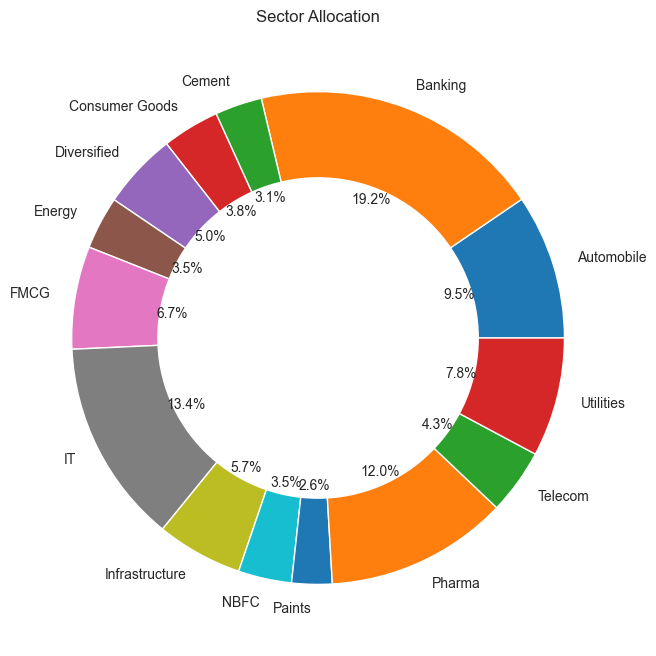

In [23]:
# Chart 17 — Sector Donut Chart
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8, 8))
plt.pie(sector, labels=sector.index, autopct="%1.1f%%")

centre = plt.Circle((0, 0), 0.65, fc="white")
plt.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.savefig(CHART_DIR / "sector_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Section 9 — EDA Insights

# 15 Key EDA Findings

## 1. Young professionals make up the majority of the investor base.
The 26-35 age group accounts for about 41% of all investors, making it the largest group in mutual fund participation.

**Supporting Chart:** Age Distribution

---

## 2. Mutual fund investing is still focused in T30 cities.
T30 cities make up almost 66% of all investor transactions, showing stronger activity in major urban areas.

**Supporting Chart:** T30 vs B30 Distribution

---

## 3. Male investors outnumber female investors.
Men participate roughly twice as much as women, highlighting a gender gap in mutual fund investing.

**Supporting Chart:** Gender Distribution

---

## 4. Industry-wide NAV has shown steady long-term growth.
Average NAV rose from around 207 in 2022 to nearly 360 by 2026, showing strong market appreciation.

**Supporting Chart:** Average Industry NAV

---

## 5. A few schemes generate very high NAV values.
The NAV distribution is heavily skewed to the right, with some schemes significantly outperforming the broader market.

**Supporting Chart:** NAV Distribution

---

## 6. SBI Mutual Fund is the industry leader in assets under management.
SBI MF consistently records the highest AUM among all fund houses, keeping a significant lead over its competitors.

**Supporting Chart:** AUM by Fund House

---

## 7. The mutual fund industry’s AUM grew significantly in 2024.
Almost every AMC saw strong AUM growth during 2024 due to favorable market conditions and increased investor participation.

**Supporting Chart:** AUM Growth by AMC

---

## 8. SIP adoption has steadily increased during the study period.
Monthly SIP inflows went up from about ₹11,500 crore in 2022 to over ₹31,000 crore by the end of 2025.

**Supporting Chart:** Monthly SIP Inflows

---

## 9. Active SIP accounts keep rising each year.
The number of active SIP accounts increased from about 5 crore to more than 9 crore, showing greater engagement among retail investors.

**Supporting Chart:** Active SIP Accounts

---

## 10. Banking and IT sectors lead equity mutual fund portfolios.
Banking makes up nearly 19% of portfolio allocation while IT accounts for over 13%, making these the two largest sectors.

**Supporting Chart:** Sector Allocation Donut Chart

---

## 11. Liquid funds attracted the most inflows within their category.
Liquid funds consistently saw the largest net inflows throughout the observed period.

**Supporting Chart:** Category Inflow Heatmap

---

## 12. Fund return correlations are usually low to moderate.
Most schemes show weak pairwise correlations, indicating diversification benefits across funds.

**Supporting Chart:** Fund Return Correlation Matrix

---

## 13. SIP growth momentum peaked in 2024.
Year-over-year SIP growth exceeded 50% at times in 2024 before normalizing in 2025.

**Supporting Chart:** SIP YoY Growth

---

## 14. Northern and southern states have significant transaction volumes.
States like Punjab, Tamil Nadu, and Madhya Pradesh are among the highest contributors in transaction amounts.

**Supporting Chart:** Transaction Amount by State

---

## 15. The top AMCs hold a large share of industry assets.
The top five fund houses control most of the total industry AUM, showing market concentration.

**Supporting Chart:** Top Fund Houses